In [1]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(R"C:\Users\Neharika\Downloads\data.csv", encoding='ISO-8859-1')

# Basic cleaning
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Convert date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Convert CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(str)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
split_date = df['InvoiceDate'].quantile(0.75)

train_df = df[df['InvoiceDate'] <= split_date]
test_df  = df[df['InvoiceDate'] > split_date]

print(train_df.shape, test_df.shape)

(298432, 9) (99452, 9)


In [4]:
def create_features(data, reference_date):
    
    customer_df = data.groupby('CustomerID').agg({
        'InvoiceDate': ['max', 'min'],
        'InvoiceNo': 'nunique',
        'Revenue': ['sum', 'mean'],
        'StockCode': 'nunique'
    }).reset_index()

    customer_df.columns = [
        'CustomerID',
        'last_purchase',
        'first_purchase',
        'frequency',
        'monetary_total',
        'avg_order_value',
        'product_diversity'
    ]

    # Recency
    customer_df['recency'] = (reference_date - customer_df['last_purchase']).dt.days

    # Tenure
    customer_df['tenure'] = (customer_df['last_purchase'] - customer_df['first_purchase']).dt.days

    # Purchase velocity
    customer_df['purchase_velocity'] = customer_df['frequency'] / (customer_df['tenure'] + 1)

    return customer_df

In [5]:
reference_date_train = train_df['InvoiceDate'].max()

train_features = create_features(train_df, reference_date_train)

In [6]:
future_revenue = test_df.groupby('CustomerID')['Revenue'].sum().reset_index()
future_revenue.columns = ['CustomerID', 'CLV']

# Merge with features
model_df = train_features.merge(future_revenue, on='CustomerID', how='left')

# Fill missing CLV (no future purchase)
model_df['CLV'] = model_df['CLV'].fillna(0)

model_df.head()

,CustomerID,last_purchase,first_purchase,frequency,monetary_total,avg_order_value,product_diversity,recency,tenure,purchase_velocity,CLV
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,1,275,0,1.000000,0.00
1,12347.0,2011-08-02 08:48:00,2010-12-07 14:57:00,5,2790.86,22.506935,82,79,237,0.021008,1519.14
2,12348.0,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,57.975484,22,25,282,0.014134,0.00
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,17,259,0,1.000000,0.00
4,12352.0,2011-09-28 14:58:00,2011-02-16 12:33:00,7,2194.31,31.347286,47,21,224,0.031111,311.73


In [7]:
features = [
    'recency',
    'frequency',
    'monetary_total',
    'avg_order_value',
    'product_diversity',
    'tenure',
    'purchase_velocity'
]

X = model_df[features]
y = model_df['CLV']

# Train-test split (within training set for validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_val)

In [9]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_val)

In [11]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)

In [12]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_val)

In [13]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R2  : {r2:.2f}")
    print("-"*30)

In [14]:
evaluate_model(y_val, lr_pred, "Linear Regression")
evaluate_model(y_val, ridge_pred, "Ridge")
evaluate_model(y_val, rf_pred, "Random Forest")
evaluate_model(y_val, xgb_pred, "XGBoost")

Linear Regression
RMSE: 1943.14
MAE : 466.54
R2  : 0.25
------------------------------
Ridge
RMSE: 1943.13
MAE : 466.54
R2  : 0.25
------------------------------
Random Forest
RMSE: 1784.69
MAE : 463.35
R2  : 0.37
------------------------------
XGBoost
RMSE: 6301.61
MAE : 676.92
R2  : -6.87
------------------------------


In [15]:
final_model = xgb_model

model_df['predicted_clv'] = final_model.predict(X)

In [16]:
model_df['segment'] = pd.qcut(
    model_df['predicted_clv'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

model_df.head()

,CustomerID,last_purchase,first_purchase,frequency,monetary_total,avg_order_value,product_diversity,recency,tenure,purchase_velocity,CLV,predicted_clv,segment
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,77183.600000,1,275,0,1.000000,0.00,22394.535156,High Value
1,12347.0,2011-08-02 08:48:00,2010-12-07 14:57:00,5,2790.86,22.506935,82,79,237,0.021008,1519.14,585.388977,High Value
2,12348.0,2011-09-25 13:13:00,2010-12-16 19:09:00,4,1797.24,57.975484,22,25,282,0.014134,0.00,426.920502,High Value
3,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,17,259,0,1.000000,0.00,66.393471,Low Value
4,12352.0,2011-09-28 14:58:00,2011-02-16 12:33:00,7,2194.31,31.347286,47,21,224,0.031111,311.73,481.869415,High Value


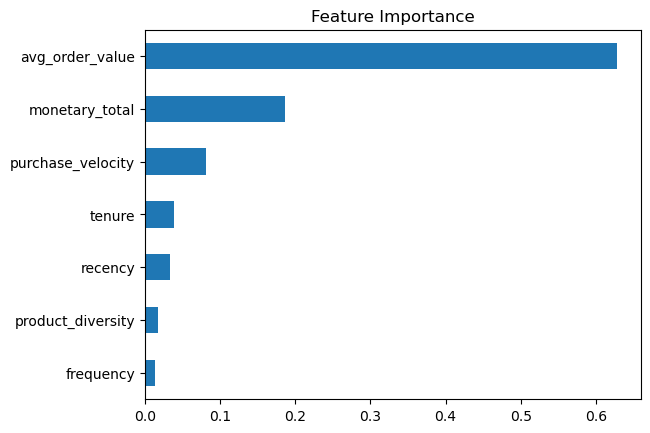

In [17]:
import matplotlib.pyplot as plt

importance = pd.Series(final_model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.show()

In [18]:
top_20 = model_df.nlargest(int(0.2 * len(model_df)), 'predicted_clv')

revenue_share = top_20['predicted_clv'].sum() / model_df['predicted_clv'].sum()

print(f"Top 20% customers contribute {revenue_share:.2%} of predicted revenue")

Top 20% customers contribute 75.63% of predicted revenue


In [19]:
# Simple churn proxy
model_df['churn_risk'] = np.where(model_df['recency'] > 90, 1, 0)

model_df['expected_value'] = model_df['predicted_clv'] * (1 - model_df['churn_risk'])

In [20]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


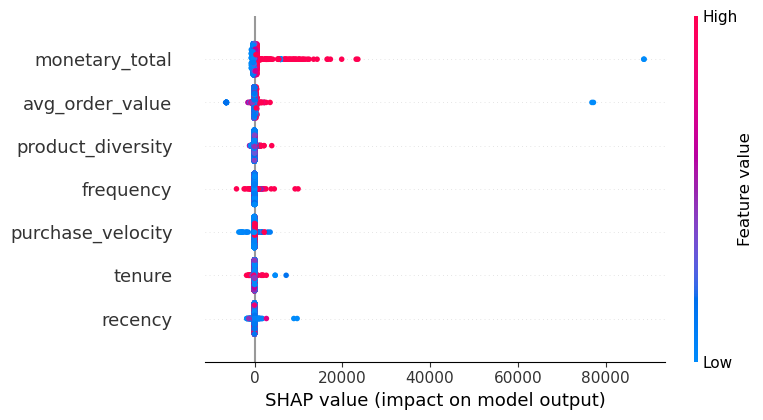

In [21]:
import shap

# Create explainer
explainer = shap.TreeExplainer(final_model)

# Compute SHAP values
shap_values = explainer.shap_values(X)

# Summary plot (global importance)
shap.summary_plot(shap_values, X)

In [23]:
# Simulate retention improvement
improved_clv = model_df['predicted_clv'] * 1.1

lift = improved_clv.sum() - model_df['predicted_clv'].sum()

print(f"Revenue increase if retention improves by 10%: {lift:.2f}")

Revenue increase if retention improves by 10%: 198636.50
